In [2]:
library(clusterProfiler)
library(ggplot2)
library(dplyr)
library(stringr)
library(enrichplot)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(viridis)
library(igraph)
library(tidygraph)
library(gridExtra)

In [3]:
de_path <- "/tscc/projects/ps-epigen/users/mpt006/scenic/liver_plots/DE_files/DE_results/"
de_files <- list.files(de_path)
de_files <- grep("scaled", de_files, value = TRUE, invert = TRUE)
#de_files

In [4]:
#hep_de <- grep("Hepatocytes", de_files, value = TRUE)
hep_de <- grep("Hepatocytes", de_files, value = TRUE)
hep_de

[1] "Hepatocytes_Age.dds.res"                     
 [2] "Hepatocytes_BMI.dds.res"                     
 [3] "Hepatocytes_Fibrosis.stage.dds.res"          
 [4] "Hepatocytes_High_Fibrosis_vs_Control.dds.res"
 [5] "Hepatocytes_Lobular.inflammation.dds.res"    
 [6] "Hepatocytes_Low_Fibrosis_vs_Control.dds.res" 
 [7] "Hepatocytes_MASH_ALL_vs_Control.dds.res"     
 [8] "Hepatocytes_MASH_vs_Control.dds.res"         
 [9] "Hepatocytes_MASH.CRN.score..X.8.dds.res"     
[10] "Hepatocytes_MASL_vs_Control.dds.res"         
[11] "Hepatocytes_MetALD_vs_Control.dds.res"       
[12] "Hepatocytes_Steatosis.grade.dds.res"

In [5]:
comps_keep <- c('Hepatocytes_Fibrosis.stage', 'Hepatocytes_Steatosis.grade')

In [6]:
#comps_keep <- c('Hepatocytes_Fibrosis.stage', 'Hepatocytes_MetALD_vs_Control', 
#                'Hepatocytes_MASH_vs_Control', 'Hepatocytes_Steatosis.grade.dds.res', 
#                'Hepatocytes_MASL_vs_Control')

In [7]:
comps_keep <- c('Hepatocytes_MetALD_vs_Control.dds.res', 
                'Hepatocytes_High_Fibrosis_vs_Control.dds.res', 'Hepatocytes_Low_Fibrosis_vs_Control.dds.res', 
                'Hepatocytes_MASH_vs_Control.dds.res', 'Hepatocytes_MASL_vs_Control')

In [8]:
#comps_keep <- c('HSC_Fibrosis.stage', 'HSC_MetALD_vs_Control', 
#                'HSC_MASH_vs_Control', 'HSC_Steatosis.grade.dds.res', 
#                'HSC_MASL_vs_Control')

In [9]:
#comps_keep <- c('Hepatocytes_MASL_vs_Control')

In [10]:
pattern <- paste(comps_keep, collapse = "|")
hep_de <- grep(pattern, hep_de, value = TRUE)
hep_de

[1] "Hepatocytes_High_Fibrosis_vs_Control.dds.res"
[2] "Hepatocytes_Low_Fibrosis_vs_Control.dds.res" 
[3] "Hepatocytes_MASH_vs_Control.dds.res"         
[4] "Hepatocytes_MASL_vs_Control.dds.res"         
[5] "Hepatocytes_MetALD_vs_Control.dds.res"

In [11]:
td <- read.table("/tscc/projects/ps-epigen/users/rlan/Liver_FNIH/Scenic/Celltype_v2/Hepatocytes_out/scplus_pipeline_otsu//Snakemake//eRegulon_direct.tsv", header = TRUE)
#td <- read.table("/tscc/lustre/ddn/scratch/rlancione/Scenic_outs/HSC_otsu/eRegulon_direct.tsv", header = TRUE)
T2G <- td[,c("eRegulon_name", "Gene")]
head(T2G)

,eRegulon_name,Gene
,<chr>,<chr>
1,AR_direct_+/+,CXCL2
2,AR_direct_+/+,TPRG1
3,AR_direct_+/+,ORAI3
4,AR_direct_+/+,ADRA1A
5,AR_direct_+/+,UGT2B7
6,AR_direct_+/+,KANTR


In [12]:
# Loop over each DE file
enrichment_results <- list()
enrichment_raw <- list()
for (file_path in hep_de) {
    # Read the CSV file
    data <- read.table(paste0(de_path,"/",file_path), sep = "\t", header = TRUE, row.names = 1)
    
    # Extract the 'stat' column and set gene names
    original_gene_list <- data$stat
    names(original_gene_list) <- rownames(data)
    
    # Remove NA values and sort in decreasing order
    gene_list <- na.omit(original_gene_list)
    gene_list <- sort(gene_list, decreasing = TRUE)
    
    # Perform GSEA
    enrichment <- GSEA(geneList = gene_list, TERM2GENE = T2G, by = "fgsea", pvalueCutoff = 1, eps=0)
    
    # Get short file name for identification
    short_name <- str_remove(file_path, "\\.dds\\.res$")
    enrichment_raw[[short_name]] <- enrichment
  
    # some conversion
    enrichment_df <- as.data.frame(enrichment)
    enrichment_df$ID <- short_name
    #enrichment_df$NESmod <- enrichment_df$NES * (1 - enrichment_df$p.adjust)
    enrichment_df$NESmod <- enrichment_df$NES
    enrichment_df <- enrichment_df[, c("NESmod", "p.adjust", "Description")]
    # Set NA values for NES to 0 and p.adjust to 1
    #enrichment_df$NESmod[is.na(enrichment_df$NESmod)] <- 0
    #enrichment_df$p.adjust[is.na(enrichment_df$p.adjust)] <- 1
    colnames(enrichment_df)[colnames(enrichment_df) == "NESmod"] <- paste(short_name, "NESmod", sep = "_")
    colnames(enrichment_df)[colnames(enrichment_df) == "p.adjust"] <- paste(short_name, "p.adjust", sep = "_")

    # add to list   
    enrichment_results[[short_name]] <- enrichment_df
    
}


preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



### Write core enrichment of GSEA to file... 

In [44]:
names(enrichment_raw)

[1] "Hepatocytes_High_Fibrosis_vs_Control"
[2] "Hepatocytes_Low_Fibrosis_vs_Control" 
[3] "Hepatocytes_MASH_vs_Control"         
[4] "Hepatocytes_MASL_vs_Control"         
[5] "Hepatocytes_MetALD_vs_Control"

In [35]:
### had list of core enrichments for that comparison. Need to pair with grns 
le_sets <- enrichment_raw$Hepatocytes_High_Fibrosis_vs_Control@result$core_enrichment
le_sets

[1] "METTL25/ANKRD50/ABCG8/SYNE1/HAO1/TRPM3/EPB41L4B/PHLPP1/MICU1/ACAA2/C5/BCAS3/F9/CYP39A1/OXR1/ADH1B/SRGAP3/TRPC5/HEATR4/PPP1R1C/ZC4H2/NADK2/CES4A/RBP4/PIPOX/PIGN/GPER1/CAMK2D/NUDT5/MTERF2/ARHGEF28/SLC2A2/ADHFE1/EPHX2/OARD1/EHHADH/LECT2/MLPH/GSAP/LDHB/SGK3/PROZ/A1CF/ST3GAL6/FYB2/TTPAL/CXCL2/ITPRID2/SHMT1/TOB1/HECTD1/FAT4/SLC22A1/CFAP57/DNAJC19/AOX1/GOT2/ADGRA3/CFAP161/NAALADL2/SLC22A10/APOC4/NOS1AP/CTSO/CNNM2/PIK3R1/BPHL/QDPR/C2orf72/AASS/GIN1/SLC22A9/SLC39A8/HORMAD2/GSTT2B/MCC/SLC6A1/CYP7B1/SCARB2/KLHDC2/N4BP2L1/AR/GAS2/PTK2B/C1RL/GBP7/PGBD5/PEX6/SUOX/UPB1/MTTP/CNST/CHIC1/FAM9B/SLC38A4/C14orf93/C1GALT1/CNPY3/KLKB1/SLC10A5/STK3/KCNK5/SC5D/SH3PXD2A/ATP7B/ENPP1/RTTN/ADH6/ETNPPL/ZFHX4/SLC16A2/MAGI3/FOLH1/SLC22A25/CYP2C19/EHBP1/CLDN14/FAM81A/GTF2IRD2B/ACSM5/SLC6A16/F13B/GPHN/GLUD1/SMIM12/CDHR3/AGL/TMEM150C/ELMO1/SHROOM2/BCKDHB/GNE/PON3/GRTP1/ACADSB/KLF12/ZKSCAN1/WNK3/ITIH2/ALDH7A1/SARDH/GYG2/BCAT2/AKR1C4/BCHE/GPRC5C/GRAMD2B/C9/SEMA4G/GLYAT/DMD/AZGP1/FANCL/TTPA/SERPINA11/CNGA1/CYP2C9/ZFP1/AMDHD1/SLC6A13/TESK2/TUBE1/AIG1/STYX/GFRA1/PCK2/NR1I3/DNAH6/HMGCS2/STPG2/FAM184A/TEF/DLG2/CYP2E1/CYP2C8/PBX3/RUNDC3B/ALDH8A1/L3MBTL3/ZNF385B/NTN1/TNRC6C/UROC1/APOH/ACOX2/EFHD1/GC/IDH1/SMARCA2/APOF/MACROD2/RDH16/NR3C2/ITCH/SUGCT/PON1/GLS2/WDR72/AADAT/ASXL3/PBLD/SLC27A5/MFAP3L/PHGDH/EFCAB13/HSD17B6/PGLYRP2/SCG5/KCNN2/HSD17B14/DCAF11/NECTIN3/MAOB/CCDC38/RAPH1/TF/COQ10A/ADCY1/CYP2B6/SLCO4C1/RBFOX2/LPA/TENM3/MTUS2/DOK6"
  [2] "ITGA2/CREB5/PTPN14/AKAP12/NRG2/DAB2/ABCC1/SOX4/LIF/GRK3/DAGLA/ITPR3/CA12/MYO7B/GAS2L3/CDK18/GPRIN3/PLCE1/AKR1B10/KIF5C/CD44/EID3/TXNRD1/UBASH3B/PRTFDC1/SUSD1/RAB8B/UGCG/CIDEC/B3GNT5/CCDC120/MCF2L2/FAT1/MICALL2/MTMR11/FLVCR2/NEDD9/MPZL3/FGF1/SDCBP2/KLHL29/OR2I1P/UBALD2/DAPK3/TES/ANKRD33/TBC1D9/PPP1R13L/DUSP8/ZNF438/ANKRD29/SLC15A4/PLXNA3/PDLIM1/LAMB3/KIF21B/LAMA3/LIMA1/MED9/TNFAIP2/BAMBI/ARHGAP22/SPG7/CDHR2/RAB5IF/CBLB/LGALS4/RAB7B/RAB10/DUSP5/SAMD4A/SLC7A6/IQGAP1/VDAC2/CELSR1/HIP1R/JPT2/MPV17/MAFK/ANXA5/SH2B3/CSNK1E/CASZ1/NIPAL2/MTHFD1L/NAV2/TMEM184B/MICAL3/ALS2CL/MAPK8IP3/FOSL1/ANKS1B/ATP8B1/CTTN/MYH9/RASA3/WDR1/IER3/PLEC/DYNC1H1/PACS1/DYNLT1/RHOQ/NEBL/HGS/RASD1/IL32"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
  [3] "HAO1/TRPM3/PHLPP1/MICU1/ACAA2/RIDA/C5/TTC36/SHOC1/RBP4/MGMT/ADI1/ARHGEF26/PIPOX/MTM1/CAMK2D/CTNNBL1/MTERF2/ARHGEF28/SLC2A2/SORD/MPHOSPH9/EPHX2/FYB2/MBNL3/SHMT1/TOB1/SLC22A1/CFAP57/APOC4/POFUT1/NOS1AP/PCYOX1/CNNM2/PIK3R1/BPHL/QDPR/ACSM1/MCC/N4BP2L1/PTK2B/C1RL/GBP7/PACRG/ARHGEF40/MDN1/FAM9B/TMEM25/C14orf93/HPX/LIG4/KLKB1/DMGDH/EXOC3L4/SH3PXD2A/FMO3/EBPL/HMGB1/RTTN/SLC16A2/MAGI3/MAT1A/FAM81A/GJB1/TMPRSS6/GLUD1/DLGAP2/MOGAT1/GATM/PON3/GRTP1/KLF12/ZKSCAN1/ALDH7A1/BCAT2/GPLD1/PLG/SEMA4G/FMO4/EBNA1BP2/TTPA/MTHFD1/CDO1/ZFP1/SLC2A4RG/AMDHD1/AIG1/ACOT13/SFXN2/ABCC9/USH2A/NR1I3/MTHFD2L/BHMT/HMGCS2/CCL16/FAM184A/GLYCTK/ALDH8A1/NTN1/TNRC6C/UROC1/HMCN1/GC/IDH1/SMARCA2/RDH16/ITCH/SUGCT/PON1/DCDC1/SOX5/THRSP/SLC27A5/CNTLN/EFCAB13/F11/CSAD/PFKFB1/HSD17B14/CCDC38/TF/KCNMA1/RBFOX2/MTUS2"                                                                                                                                                                                                                                                                                                                                                                                    

In [37]:
grns <- enrichment_raw$Hepatocytes_High_Fibrosis_vs_Control@result$ID
#grns

In [34]:
length(le)
length(grn)

[1] 202

[1] 202

In [52]:
for (i in seq(1, length(2))){
    grn <- grns[i]
    grn <- str_replace(grn, "/", ".")
    print(grn)
    le <- le_sets[i]
    le_split <- str_split(string = le, pattern = "/")

    print(le_split)
    write.table(le_split, file = paste0("leading_edges/", grn, "_le.txt"), quote = FALSE, col.names = FALSE, row.names = FALSE)
    
}
    

[1] "KLF12_direct_+.+"
[[1]]
  [1] "METTL25"   "ANKRD50"   "ABCG8"     "SYNE1"     "HAO1"      "TRPM3"    
  [7] "EPB41L4B"  "PHLPP1"    "MICU1"     "ACAA2"     "C5"        "BCAS3"    
 [13] "F9"        "CYP39A1"   "OXR1"      "ADH1B"     "SRGAP3"    "TRPC5"    
 [19] "HEATR4"    "PPP1R1C"   "ZC4H2"     "NADK2"     "CES4A"     "RBP4"     
 [25] "PIPOX"     "PIGN"      "GPER1"     "CAMK2D"    "NUDT5"     "MTERF2"   
 [31] "ARHGEF28"  "SLC2A2"    "ADHFE1"    "EPHX2"     "OARD1"     "EHHADH"   
 [37] "LECT2"     "MLPH"      "GSAP"      "LDHB"      "SGK3"      "PROZ"     
 [43] "A1CF"      "ST3GAL6"   "FYB2"      "TTPAL"     "CXCL2"     "ITPRID2"  
 [49] "SHMT1"     "TOB1"      "HECTD1"    "FAT4"      "SLC22A1"   "CFAP57"   
 [55] "DNAJC19"   "AOX1"      "GOT2"      "ADGRA3"    "CFAP161"   "NAALADL2" 
 [61] "SLC22A10"  "APOC4"     "NOS1AP"    "CTSO"      "CNNM2"     "PIK3R1"   
 [67] "BPHL"      "QDPR"      "C2orf72"   "AASS"      "GIN1"      "SLC22A9"  
 [73] "SLC39A8"   "HORMAD2"   "GSTT

In [58]:
for (n in names(enrichment_raw)){
    print(n)
    temp_enrichment <- enrichment_raw[[n]]
    dir.create(path = paste0("leading_edges/", n), showWarnings = FALSE)

    grns <- temp_enrichment@result$ID
    le_sets <- temp_enrichment@result$core_enrichment

    for (i in seq(1, length(grns))){
        grn <- grns[i]
        grn <- str_replace(grn, "/", ".")
        print(grn)
        le <- le_sets[i]
        le_split <- str_split(string = le, pattern = "/")
    
        print(le_split)
        write.table(le_split, file = paste0("leading_edges/",n,"/", grn, "_le.txt"), quote = FALSE, col.names = FALSE, row.names = FALSE)
        
    }    

  
    
}

[1] "Hepatocytes_High_Fibrosis_vs_Control"
[1] "KLF12_direct_+.+"
[[1]]
  [1] "METTL25"   "ANKRD50"   "ABCG8"     "SYNE1"     "HAO1"      "TRPM3"    
  [7] "EPB41L4B"  "PHLPP1"    "MICU1"     "ACAA2"     "C5"        "BCAS3"    
 [13] "F9"        "CYP39A1"   "OXR1"      "ADH1B"     "SRGAP3"    "TRPC5"    
 [19] "HEATR4"    "PPP1R1C"   "ZC4H2"     "NADK2"     "CES4A"     "RBP4"     
 [25] "PIPOX"     "PIGN"      "GPER1"     "CAMK2D"    "NUDT5"     "MTERF2"   
 [31] "ARHGEF28"  "SLC2A2"    "ADHFE1"    "EPHX2"     "OARD1"     "EHHADH"   
 [37] "LECT2"     "MLPH"      "GSAP"      "LDHB"      "SGK3"      "PROZ"     
 [43] "A1CF"      "ST3GAL6"   "FYB2"      "TTPAL"     "CXCL2"     "ITPRID2"  
 [49] "SHMT1"     "TOB1"      "HECTD1"    "FAT4"      "SLC22A1"   "CFAP57"   
 [55] "DNAJC19"   "AOX1"      "GOT2"      "ADGRA3"    "CFAP161"   "NAALADL2" 
 [61] "SLC22A10"  "APOC4"     "NOS1AP"    "CTSO"      "CNNM2"     "PIK3R1"   
 [67] "BPHL"      "QDPR"      "C2orf72"   "AASS"      "GIN1"      "SLC

### back to results table and Mai's work

In [13]:
names(enrichment_results)

[1] "Hepatocytes_High_Fibrosis_vs_Control"
[2] "Hepatocytes_Low_Fibrosis_vs_Control" 
[3] "Hepatocytes_MASH_vs_Control"         
[4] "Hepatocytes_MASL_vs_Control"         
[5] "Hepatocytes_MetALD_vs_Control"

In [14]:
#final_enrichment <- enrichment_results[[1]]

In [15]:
# Merge all the results into a final dataframe based on Description (row names)
final_enrichment <- Reduce(function(x, y) merge(x, y, by = "Description", all = TRUE), enrichment_results)
# View the final merged enrichment data
final_enrichment <- final_enrichment[apply(final_enrichment, 1, function(row) !all(is.na(row))), ]
#final_enrichment <- final_enrichment[final_enrichment$Hepatocytes_MASL_vs_Control_p.adjust < 0.05, ]
#final_enrichment <- final_enrichment[final_enrichment$Hepatocytes_MASL_vs_Control_p.adjust < 0.05, ] 

In [16]:
enrichment_results[[1]]

,Hepatocytes_High_Fibrosis_vs_Control_NESmod,Hepatocytes_High_Fibrosis_vs_Control_p.adjust,Description
,<dbl>,<dbl>,<chr>
KLF12_direct_+/+,-3.604317,4.610145e-73,KLF12_direct_+/+
CREB5_direct_+/+,3.261911,2.715954e-40,CREB5_direct_+/+
KLF12_direct_+/-,-3.416024,1.546930e-39,KLF12_direct_+/-
NFIA_direct_+/+,-2.894589,7.714963e-38,NFIA_direct_+/+
KLF6_direct_+/-,2.798061,3.851803e-36,KLF6_direct_+/-
FLI1_direct_+/+,2.855796,3.678797e-34,FLI1_direct_+/+
ETS1_direct_+/+,2.771481,2.276234e-30,ETS1_direct_+/+
E2F3_direct_+/-,2.931676,7.455379e-30,E2F3_direct_+/-
TFDP2_direct_+/+,-3.285417,4.790353e-26,TFDP2_direct_+/+


In [17]:
nrow(final_enrichment)
head(final_enrichment)
any(is.na(final_enrichment))

[1] 202

,Description,Hepatocytes_High_Fibrosis_vs_Control_NESmod,Hepatocytes_High_Fibrosis_vs_Control_p.adjust,Hepatocytes_Low_Fibrosis_vs_Control_NESmod,Hepatocytes_Low_Fibrosis_vs_Control_p.adjust,Hepatocytes_MASH_vs_Control_NESmod,Hepatocytes_MASH_vs_Control_p.adjust,Hepatocytes_MASL_vs_Control_NESmod,Hepatocytes_MASL_vs_Control_p.adjust,Hepatocytes_MetALD_vs_Control_NESmod,Hepatocytes_MetALD_vs_Control_p.adjust
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AFF4_direct_+/-,1.622663,2.391258e-02,-0.6921536,0.943350254,1.536048,3.691384e-02,-2.340578,3.888835e-07,0.7258629,0.895266113
2,AHR_direct_+/-,-1.284375,1.360422e-01,-1.8634482,0.003514836,-1.903738,1.299585e-03,1.116952,3.482203e-01,-1.1681990,0.296306873
3,AR_direct_+/+,-2.927932,2.062205e-12,-1.1936969,0.305809394,-2.647292,1.780156e-09,2.307628,1.056246e-06,-1.6704371,0.008418343
4,ATF2_direct_+/-,-1.504492,4.061942e-02,-1.7172434,0.006869710,-1.724723,3.475016e-03,-0.962986,5.784309e-01,-1.0651712,0.445067368
5,ATF3_direct_+/-,1.553769,5.070295e-02,-0.8861817,0.738915358,1.458751,8.093614e-02,-2.295064,4.456013e-07,1.0844151,0.405073917
6,ATF3_direct_+/+,2.125843,2.824604e-09,1.3807042,0.047067559,1.881262,5.518107e-06,-3.310303,5.292784e-48,-1.3002299,0.070490756


[1] FALSE

In [18]:
p_adjust_columns <- grep ("p.adjust", colnames(final_enrichment), value = TRUE)
## only keep rows with at least one p.adjust column significant
filtered_df <- final_enrichment[rowSums(final_enrichment[, p_adjust_columns] <= 0.05) > 0, ]

#head(filtered_df, 5)
nrow(filtered_df)

[1] 183

In [19]:
#write.csv(filtered_df, "fGSEA_NESmod_GRN_liver.csv", row.names = FALSE)

In [20]:
#filtered_df <- final_enrichment

In [21]:
filtered_df <- filtered_df %>%
  filter(!grepl("_direct_\\+/-", Description))

In [22]:
filtered_df <- filtered_df %>%
  filter(!grepl("_direct_\\-/-", Description))

In [23]:
#one <- filtered_df %>%
#  filter(grepl("_direct_\\-/+", Description))

In [24]:
filtered_df <- filtered_df %>%
  filter(!grepl("_direct_\\-/+", Description))

In [25]:
nrow(filtered_df)

[1] 94

In [26]:
head(filtered_df)

,Description,Hepatocytes_High_Fibrosis_vs_Control_NESmod,Hepatocytes_High_Fibrosis_vs_Control_p.adjust,Hepatocytes_Low_Fibrosis_vs_Control_NESmod,Hepatocytes_Low_Fibrosis_vs_Control_p.adjust,Hepatocytes_MASH_vs_Control_NESmod,Hepatocytes_MASH_vs_Control_p.adjust,Hepatocytes_MASL_vs_Control_NESmod,Hepatocytes_MASL_vs_Control_p.adjust,Hepatocytes_MetALD_vs_Control_NESmod,Hepatocytes_MetALD_vs_Control_p.adjust
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AR_direct_+/+,-2.9279322,2.062205e-12,-1.1936969,3.058094e-01,-2.6472919,1.780156e-09,2.307628,1.056246e-06,-1.6704371,8.418343e-03
2,ATF3_direct_+/+,2.1258434,2.824604e-09,1.3807042,4.706756e-02,1.8812617,5.518107e-06,-3.310303,5.292784e-48,-1.3002299,7.049076e-02
3,ATF5_direct_+/+,1.4943185,3.038703e-02,-1.2103338,2.614600e-01,1.2181842,2.202343e-01,-2.428088,1.297315e-10,-1.3108476,1.064348e-01
4,ATF6_direct_+/+,-0.8080998,9.716347e-01,0.9703834,6.564377e-01,-0.8422267,9.443277e-01,-2.873155,1.433564e-30,-2.2876206,1.158639e-11
5,BACH2_direct_+/+,-1.0628111,2.812560e-01,-2.4159932,1.340036e-19,-1.6371104,1.447475e-06,-3.194107,9.739036e-73,-1.1213075,1.689296e-01
6,CEBPD_direct_+/+,-1.1218715,2.962453e-01,-1.7060563,1.332386e-02,-1.3319997,1.197658e-01,-2.087176,1.363907e-05,-0.9290486,6.492799e-01


In [29]:
#write.csv(filtered_df, "fGSEA_NES_GRN_liver.csv", row.names = FALSE)
write.csv(filtered_df, "my_plots/fGSEA_NES_GRN_liver_Hep_pairwise.csv", row.names = FALSE)

### vertical heatmap

In [30]:
# Separate the NESmod and p.adjust columns dynamically
nesmod_columns <- grep("NESmod", colnames(filtered_df), value = TRUE)
#nesmod_columns <- grep("MASL_vs_Control", colnames(filtered_df), value = TRUE)
padj_columns <- grep("p.adjust", colnames(filtered_df), value = TRUE)

# Extract NESmod and p.adjust values
nesmod <- filtered_df %>% select(all_of(nesmod_columns))
nesmod <- as.matrix(nesmod)
rownames(nesmod) <- filtered_df$Description
p_adjust <- filtered_df %>% select(all_of(padj_columns))

colnames(nesmod) <- gsub(".NESmod", "", colnames(nesmod))
colnames(nesmod) <- gsub("Hepatocytes_", "", colnames(nesmod))
# Create a matrix for asterisks based on p.adjust values (significant p.adjust < 0.05)
asterisks <- ifelse(p_adjust < 0.05, "*", NA)

# Make sure the row names match (use 'Description' as row names)
rownames(asterisks) <- filtered_df$Description
asterisks <- as.matrix(asterisks)
# Create the heatmap with annotation
p <- Heatmap(
  nesmod,
  name = "Normalized Enrichment Score",
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_names_side = "left",
  column_names_side = "top",
    #transpose = TRUE,
  cell_fun = function(j, i, x, y, w, h, fill) {
    if (!is.na(asterisks[i, j])) {  # Only add asterisk if significant
      grid.text(asterisks[i, j], x, y, gp = gpar(fontsize = 10, col = "black"))
    }
  }
)

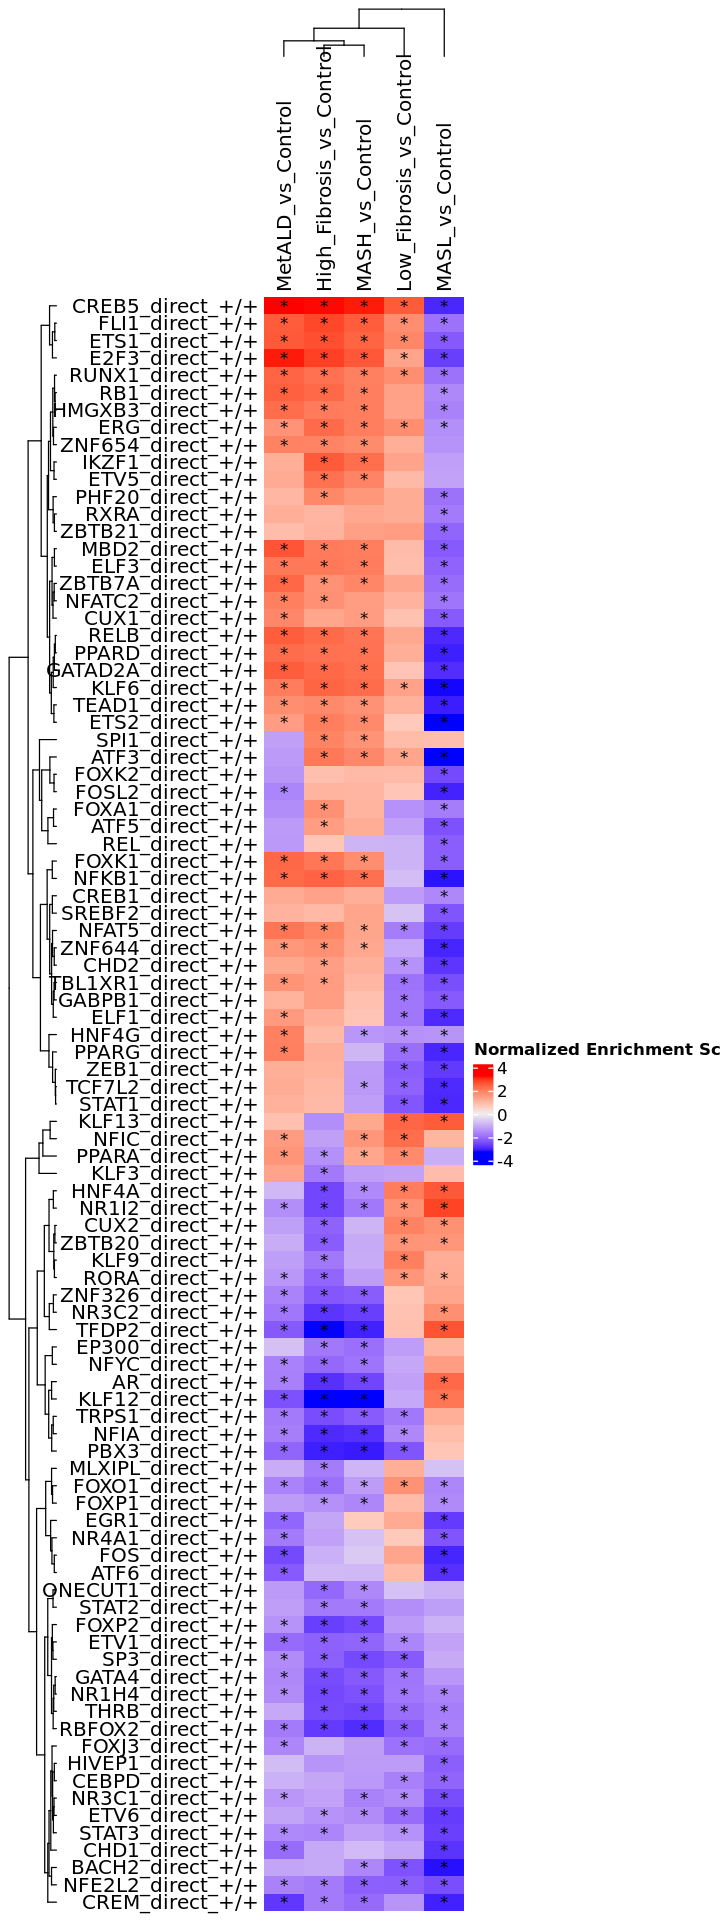

In [32]:
options(repr.plot.width = 6, repr.plot.height = 16)
p

In [57]:
#p@matrix

### horitzontal heatmap

In [51]:
filtered_df$Description <- gsub("_direct_\\+\\/\\+", "", filtered_df$Description)
head(filtered_df$Description)

[1] "AR"    "ATF3"  "ATF5"  "ATF6"  "BACH2" "CEBPD"

In [52]:
nrow(filtered_df)

[1] 93

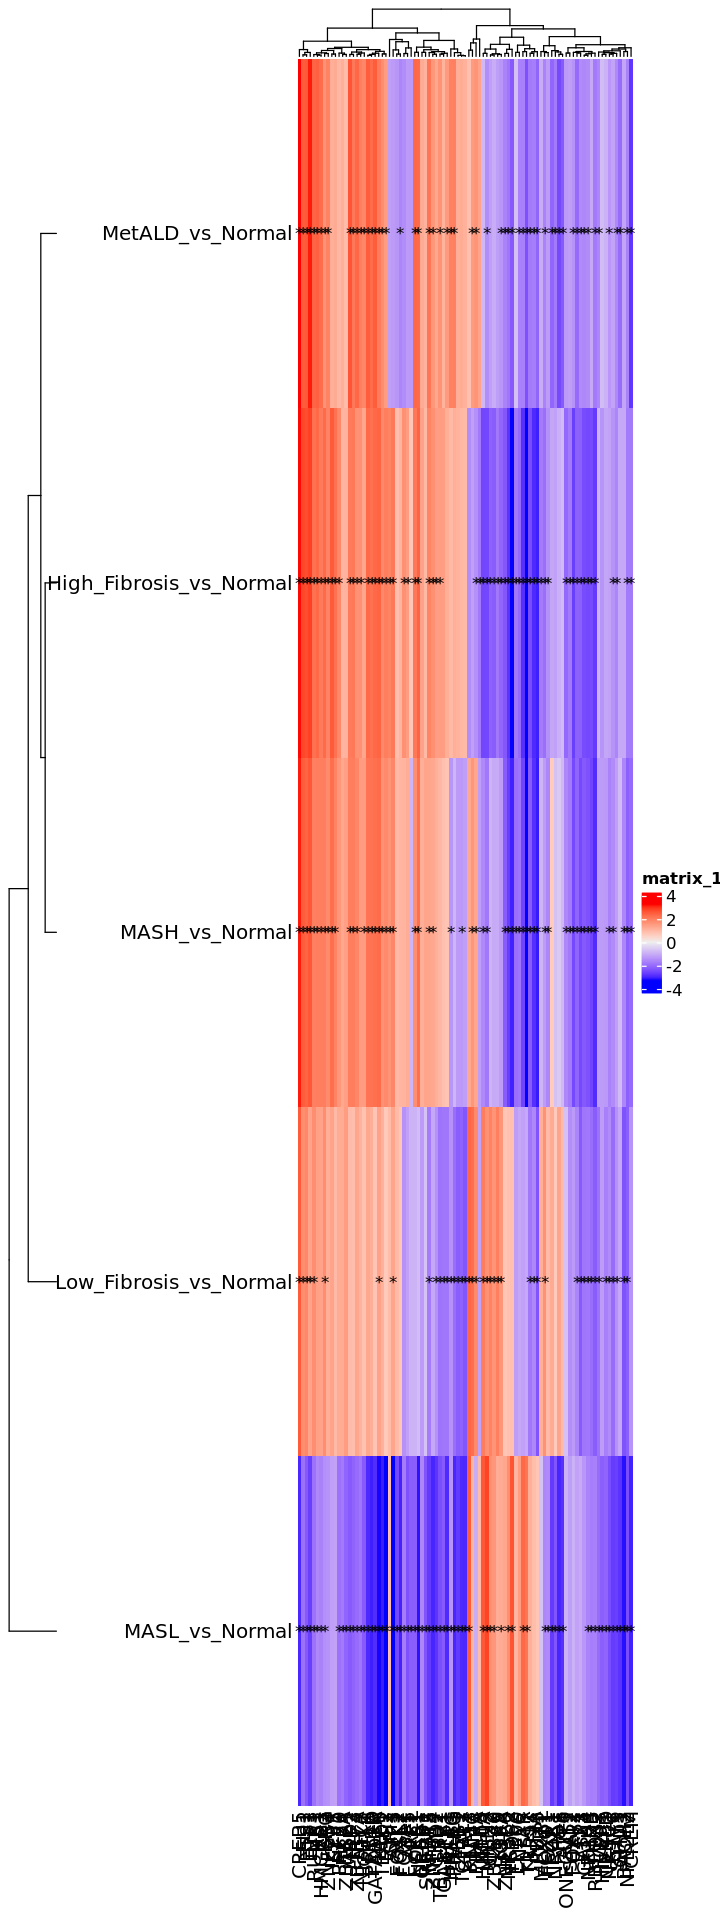

In [53]:
# Separate the NESmod and p.adjust columns dynamically
nesmod_columns <- grep("NESmod", colnames(filtered_df), value = TRUE)
padj_columns <- grep("p.adjust", colnames(filtered_df), value = TRUE)

# Extract NESmod and p.adjust values
nesmod <- filtered_df %>% select(all_of(nesmod_columns))
nesmod <- as.matrix(nesmod)
rownames(nesmod) <- filtered_df$Description
p_adjust <- filtered_df %>% select(all_of(padj_columns))

colnames(nesmod) <- gsub(".NESmod", "", colnames(nesmod))
#colnames(nesmod) <- gsub("Hepatocytes_", "", colnames(nesmod))
colnames(nesmod) <- gsub("Hepatocytes_", "", colnames(nesmod))
colnames(nesmod) <- gsub("Control", "Normal", colnames(nesmod))

# Create a matrix for asterisks based on p.adjust values (significant p.adjust < 0.05)
asterisks <- ifelse(p_adjust < 0.05, "*", NA)

# Make sure the row names match (use 'Description' as row names)
rownames(asterisks) <- filtered_df$Description
asterisks <- as.matrix(asterisks)

# Transpose nesmod and asterisks matrices
nesmod <- t(nesmod)
asterisks <- t(asterisks)

# Create the heatmap with annotation (after transposing the matrices)
p <- Heatmap(
  nesmod,
  #name = "Enrichment Score",
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_names_side = "left",  # Row names on the left
  column_names_side = "bottom",  # Column names on the top
  cell_fun = function(j, i, x, y, w, h, fill) {
    if (!is.na(asterisks[i, j])) {  # Only add asterisk if significant
      grid.text(asterisks[i, j], x, y, gp = gpar(fontsize = 10, col = "black"))
    }
  },
    show_heatmap_legend = TRUE
)

# Show the heatmap
print(p)


In [54]:
# save to file
pdf("my_plots/fGSEA_scenic_GRN_liver_final_pairwise.pdf", width = 16, height = 3)  # Adjust the dimensions as needed
print(p)
dev.off()

png 
  2

In [38]:
pdf("fGSEA_scenic_GRN_liver_final_fibrosis_steatosis.pdf", width = 16, height = 2)  # Adjust the dimensions as needed
print(p)
dev.off()

png 
  2

## second heatmap

In [35]:
one$Description <- gsub("_direct_\\-\\/\\+", "", one$Description)
head(one$Description)

ERROR: Error in eval(expr, envir, enclos): object 'one' not found


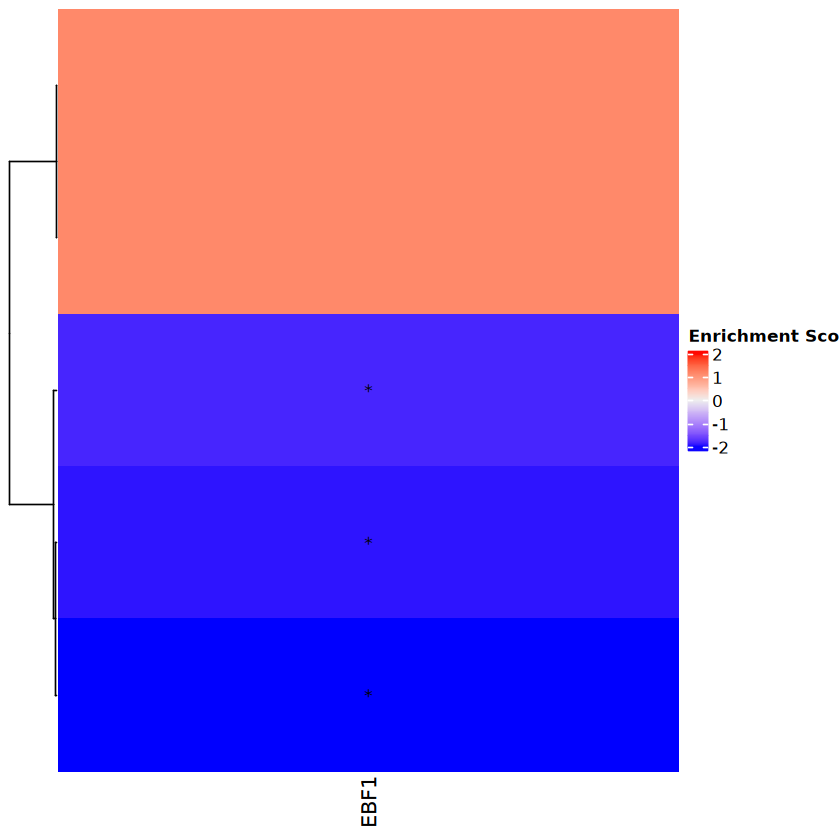

In [77]:
# Define the desired order for the rows
desired_order <- c("Fibrosis.stage", "MASH_vs_Control", "MetALD_vs_Control", "Steatosis.grade", "MASL_vs_Control")

# Separate the NESmod and p.adjust columns dynamically
nesmod_columns <- grep("NESmod", colnames(one), value = TRUE)
padj_columns <- grep("p.adjust", colnames(one), value = TRUE)

# Extract NESmod and p.adjust values
nesmod <- one %>% select(all_of(nesmod_columns))
colnames(nesmod) <- gsub("_NESmod", "", colnames(nesmod))
#colnames(nesmod) <- gsub("Hepatocytes_", "", colnames(nesmod))
colnames(nesmod) <- gsub("HSC_", "", colnames(nesmod))

p_adjust <- one %>% select(all_of(padj_columns))
colnames(p_adjust) <- gsub("_p.adjust", "", colnames(p_adjust))
#colnames(nesmod) <- gsub("Hepatocytes_", "", colnames(nesmod))
colnames(p_adjust) <- gsub("HSC_", "", colnames(p_adjust))

# Reorder the nesmod matrix based on the desired order of rows
nesmod <- nesmod[, desired_order]  # Reorder rows based on desired_order
p_adjust <- p_adjust[, desired_order]  # Reorder asterisks matrix similarly


# Create a matrix for asterisks based on p.adjust values (significant p.adjust < 0.05)
asterisks <- ifelse(p_adjust < 0.05, "*", NA)

# Make sure the row names match (use 'Description' as row names)
rownames(asterisks) <- one$Description
rownames(nesmod) <- one$Description
asterisks <- as.matrix(asterisks)
nesmod <- as.matrix(nesmod)


# Transpose nesmod and asterisks matrices
nesmod <- t(nesmod)
asterisks <- t(asterisks)

# Create the heatmap with annotation (after transposing the matrices)
p1 <- Heatmap(
  nesmod,
  name = "Enrichment Score",
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  show_row_names = FALSE,  # Row names on the left
  column_names_side = "bottom",  # Column names on the top
  cell_fun = function(j, i, x, y, w, h, fill) {
    if (!is.na(asterisks[i, j])) {  # Only add asterisk if significant
      grid.text(asterisks[i, j], x, y, gp = gpar(fontsize = 10, col = "black"))
    }
  }
)

# Show the heatmap
print(p1)


In [84]:
# save to file
pdf("fGSEA_scenic_GRN_liver_final_HSC3.pdf", width = 2, height = 2.5)  # Adjust the dimensions as needed
print(p1)
dev.off()

png 
  2

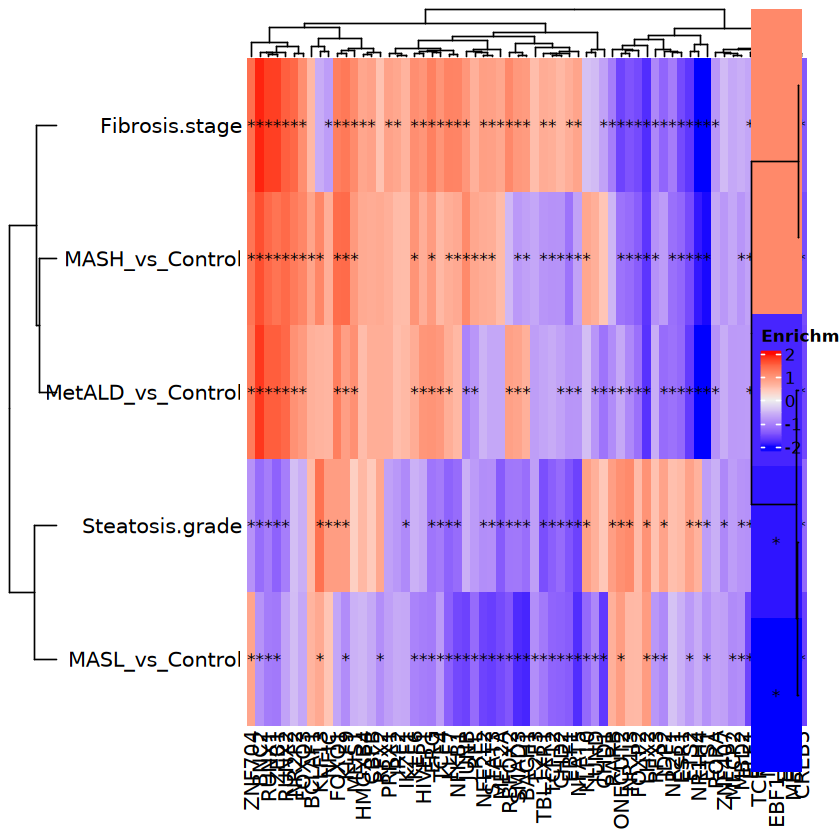

In [79]:
# Convert the heatmaps to grob objects
p_grob <- grid.grabExpr(print(p))
p1_grob <- grid.grabExpr(print(p1))

# Adjust the width ratio to give more space to p (the larger heatmap)
grid.arrange(p_grob, p1_grob, ncol = 2, widths = c(66, 2))

## subset of GRN

In [45]:
head(filtered_df)

,Description,Hepatocytes_Fibrosis.stage_NESmod,Hepatocytes_Fibrosis.stage_p.adjust,Hepatocytes_MASH_vs_Control_NESmod,Hepatocytes_MASH_vs_Control_p.adjust,Hepatocytes_MASL_vs_Control_NESmod,Hepatocytes_MASL_vs_Control_p.adjust,Hepatocytes_MetALD_vs_Control_NESmod,Hepatocytes_MetALD_vs_Control_p.adjust,Hepatocytes_Steatosis.grade_NESmod,Hepatocytes_Steatosis.grade_p.adjust
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AR,-2.7953487,1.019430e-12,-2.562414,8.805083e-09,2.366079,1.146274e-06,-1.6966569,9.238097e-03,0.6473491,9.920844e-01
2,ATF3,2.2086019,5.878029e-11,1.904266,3.995470e-06,-3.303951,6.494857e-48,-1.2825257,8.404499e-02,-2.6000842,2.260315e-17
3,ATF5,1.2302731,1.821445e-01,1.222969,2.034085e-01,-2.397682,8.538540e-10,-1.3215318,1.103172e-01,-1.8281790,8.204743e-04
4,ATF6,-0.8314816,9.739583e-01,-0.839663,9.564394e-01,-2.848955,1.987203e-30,-2.2675760,1.828416e-11,-1.9934564,7.912511e-08
5,BACH2,1.5031903,3.524191e-04,-1.641177,2.832285e-06,-3.190574,8.015872e-72,-1.1126127,2.074835e-01,-2.6472706,3.666090e-31
6,CEBPD,1.0215548,4.802103e-01,-1.289293,1.307853e-01,-2.101197,1.462081e-05,-0.9436313,6.304950e-01,-2.0208363,1.718813e-04


In [46]:
chosen = c("NR1I2", "TFDP2", "HNF4A", "KLF13", "AR", 
           "KLF12", "NR3C2", "CUX2", "RORA", "FOSL2", 
           "CREM", "PPARD", "TEAD1", "NFKB1", "BACH2",
           "KLF6", "ATF3", "ETS2")

In [48]:
subset <- filtered_df[filtered_df$Description %in% chosen, ]
nrow(subset)

[1] 18

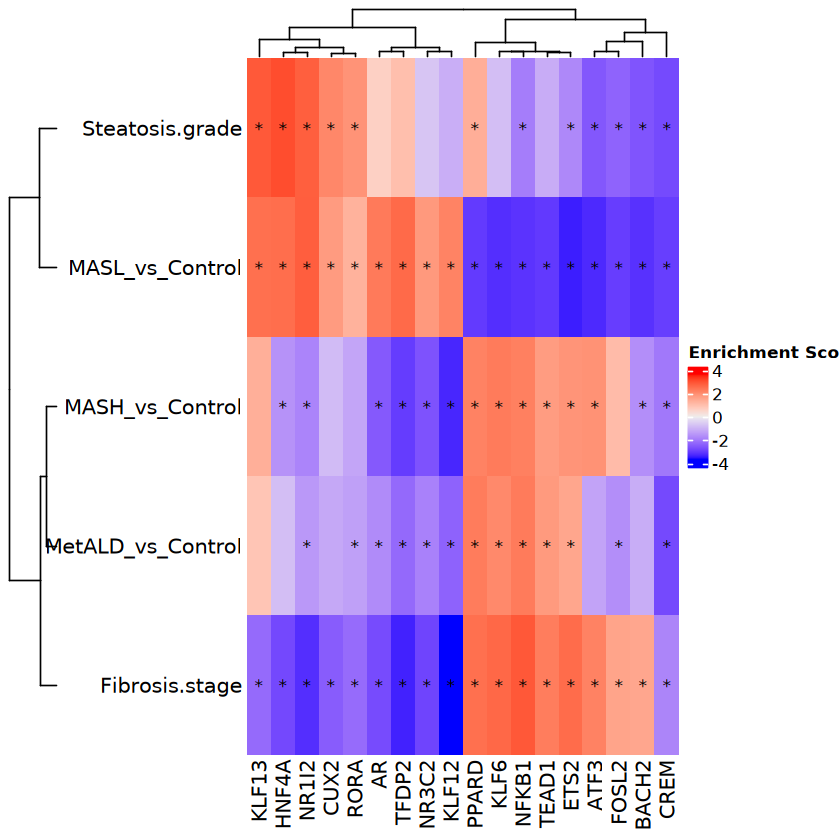

In [56]:
# Separate the NESmod and p.adjust columns dynamically
nesmod_columns <- grep("NESmod", colnames(subset), value = TRUE)
padj_columns <- grep("p.adjust", colnames(subset), value = TRUE)

# Extract NESmod and p.adjust values
nesmod <- subset %>% select(all_of(nesmod_columns))
nesmod <- as.matrix(nesmod)
rownames(nesmod) <- subset$Description
p_adjust <- subset %>% select(all_of(padj_columns))

colnames(nesmod) <- gsub(".NESmod", "", colnames(nesmod))
colnames(nesmod) <- gsub("Hepatocytes_", "", colnames(nesmod))

# Create a matrix for asterisks based on p.adjust values (significant p.adjust < 0.05)
asterisks <- ifelse(p_adjust < 0.05, "*", NA)

# Make sure the row names match (use 'Description' as row names)
rownames(asterisks) <- subset$Description
asterisks <- as.matrix(asterisks)

# Transpose nesmod and asterisks matrices
nesmod <- t(nesmod)
asterisks <- t(asterisks)

# Create the heatmap with annotation (after transposing the matrices)
p1 <- Heatmap(
  nesmod,
  name = "Enrichment Score",
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_names_side = "left",  # Row names on the left
  column_names_side = "bottom",  # Column names on the top
  cell_fun = function(j, i, x, y, w, h, fill) {
    if (!is.na(asterisks[i, j])) {  # Only add asterisk if significant
      grid.text(asterisks[i, j], x, y, gp = gpar(fontsize = 10, col = "black"))
    }
  }
)

# Show the heatmap
print(p1)


In [57]:
# save to file
pdf("fGSEA_scenic_GRN_liver_subset.pdf", width = 7, height = 3)  # Adjust the dimensions as needed
draw(p1)
dev.off()

png 
  2

## filter out +/- when plotting

In [ ]:
## filter with row names for everything not +/-

## network plot

In [8]:
## from the list of enrichment result, find out what's in it
names(enrichment_raw)

[1] "Hepatocytes_Fibrosis.stage"    "Hepatocytes_MASH_vs_Control"  
[3] "Hepatocytes_MASL_vs_Control"   "Hepatocytes_MetALD_vs_Control"
[5] "Hepatocytes_Steatosis.grade"

In [9]:
#extract the result you want
test <- enrichment_raw[["Hepatocytes_MASH_vs_Control"]]
data <- read.table(paste0(de_path,"/", "Hepatocytes_MASH_vs_Control.dds.res"), sep = "\t", header = TRUE, row.names = 1)

In [10]:
gsea_table <- test@result

# Step 2: Filter rows with +/+
gsea_table <- gsea_table %>%
  filter(grepl("\\+/\\+", Description))
gsea_table$ID <- gsub("_direct.*", "", gsea_table$ID)
gsea_table$Description <- gsub("_direct.*", "", gsea_table$Description)
rownames(gsea_table) <- gsub("_direct.*", "", rownames(gsea_table))
test@result <- gsea_table
# View the filtered table
head(test)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
KLF12,KLF12,KLF12,359,-0.6232090,-3.271028,8.806129e-56,1.778838e-53,6.581423e-54,5946,"tags=55%, list=20%, signal=45%",HECTD1/AOX1/BPHL/CYP39A1/CNST/NTN1/FAM81A/PGBD5/LRRC8A/CNNM2/SLC38A4/MAOA/RFX7/SEMA5A/PIK3R1/AASS/CYP4F3/UPB1/SLC22A25/CFAP57/CYP2E1/NIT2/OTC/GIN1/SC5D/GBP7/ING3/SCAPER/FOLH1/TMEM150C/HORMAD2/C14orf93/HAO1/NADK2/GSAP/A1CF/GPRC5C/PON3/LDLRAD4/PIAS1/DLG2/SEMA4G/CCDC152/ALB/ST3GAL6/ANKRD50/SLC10A5/FRRS1/THNSL2/TTPAL/GNE/ATP7B/CTSO/TDO2/ADH1B/ACSM5/CYP2B6/SLC22A9/ABCA5/AKR1C4/ALDH8A1/PHLPP1/SLC16A2/C2orf72/GLYAT/SUOX/CDHR3/METTL25/PPP1R1C/FAM184A/AR/SELENOP/GLUD1/TEF/GPER1/ZKSCAN1/CYP2C9/CXCL2/ALDH7A1/TUBE1/SLC6A16/RTTN/EHBP1/AMDHD1/MAML3/C9/CAMK2D/LRRC28/TTPA/PCK2/MANEA/SCARB2/CYP2C8/GRTP1/FBXL3/KLHDC2/BCKDHB/CNPY3/NR1I3/BCHE/BCAT2/SLC2A2/HSD17B13/AGL/IL1RAPL2/SLC6A13/HSD17B6/ZNF385B/SERPINA11/C1RL/CLRN3/APOC4/KLF12/GAS2/TRPM3/SLC39A8/RUNDC3B/LECT2/STK3/ENPP1/NAALADL2/KCNK5/F13B/ITPRID2/ADH6/IDH1/SLC22A10/MTERF2/DNAJC19/DCAF11/CYP7B1/ITCH/TESK2/FAT4/RDH16/PBLD/STPG2/DNAH6/CNGA1/DMD/SHROOM2/ELMO1/UROC1/PTK2B/GRAMD2B/GYG2/ZFHX4/STYX/NOS1AP/SLC27A5/ACOX2/ADCY1/COQ10A/CHIC1/AADAT/MAGI3/GLS2/MCC/WNK3/MFAP3L/MACROD2/SUGCT/PON1/CCDC38/TNRC6C/NR3C2/APOH/APOF/RAPH1/PHGDH/MAOB/GPHN/NECTIN3/FANCL/WDR72/GFRA1/SMARCA2/SH3PXD2A/ARHGEF28/C1GALT1/TF/L3MBTL3/AIG1/PGLYRP2/ASXL3/SCG5/GC/ITIH2/CYP2C19/LPA/PBX3/EFCAB13/TENM3/HSD17B14/RBFOX2/DOK6/SLCO4C1/MTUS2/EFHD1
NFIA,NFIA,NFIA,403,-0.5443521,-2.869934,1.039666e-40,1.050063e-38,3.885069e-39,6269,"tags=51%, list=21%, signal=41%",DPH6/SEC14L2/LMBRD1/STRADB/LARP1B/ESD/ENTPD5/CEP63/SMC6/HECTD1/AOX1/MGMT/PLEKHM3/OCIAD1/CYP39A1/EEA1/HIKESHI/LRRC8A/DMAC2L/CNNM2/ESR1/ABCC9/PIK3R1/HDHD3/NOL4/NHLRC3/RCOR3/ANKFY1/PPP1R3C/MAT1A/HMGB1/NIT2/EXOC4/OTC/GBP7/NUP210/MAP2K6/ARHGAP32/NADK2/ADI1/GSAP/A1CF/ST7/IMPA1/MAP3K13/MTHFD1/GTPBP10/LDLRAD4/TIGD2/CEP57L1/VSNL1/DLG2/CCDC152/IRS1/AKR1C3/ALB/BACE1/DDX17/GSTZ1/SLC10A5/ZNF326/ZNF652/DBT/IMMP2L/AOPEP/ATP7B/CTSO/GCFC2/HMCN1/RNLS/FGGY/L2HGDH/DSE/TDO2/ADH1B/CYP2B6/COG2/DDAH1/SLC2A12/ACVR1/CCDC126/GPLD1/ATF7IP/MAN1A2/ALDH8A1/ZNF516/PHLPP1/GLYAT/RESF1/SELENOP/TBX3/TRIM24/HSD17B11/LRBA/LRMDA/SLC41A2/MAML3/ATP9B/CAMK2D/TTC6/ARHGEF26/AUTS2/PCK2/SLC17A1/ANKRD46/CYP2C8/SNTG1/PUDP/ZNF704/PRODH2/CFI/EXPH5/KLHDC2/ACOT13/BCKDHB/ZEB1/NR1I3/SLC25A13/BCHE/HSD17B13/AGL/LMO7/FMO3/MAGI1/NEU3/ETFRF1/CDO1/TBC1D1/CLRN3/ADH4/FN1/SGMS1/GAS2/GEN1/MME/DIAPH2/KLB/TRPM3/MNAT1/MVK/FBXL17/LECT2/ENPP1/NAALADL2/LRRK2/CDK14/DPYS/ADH6/IDH1/MRPS28/CYP7B1/TMEM176B/PTCD2/RASGEF1B/XRN1/AMOTL1/STPG2/DCUN1D4/CNGA1/PACRG/ELMO1/NCOR1/GRAMD2B/BBOX1/HRG/NOS1AP/STRBP/HIVEP3/RAI14/CNDP1/FCHSD2/CYP2A7/CPED1/ACOX2/IQGAP2/CCDC73/PARD3/MYO16/BCO2/ADH1A/CNTLN/MDN1/APOH/KCNMA1/MCCC2/RAPH1/PHGDH/MMUT/SP4/KCNJ3/RAP1GDS1/IGF1/GFRA1/FETUB/TF/AIG1/SERPIND1/SPART/NIPAL1/ITPR2/CHD6/PCOLCE2/EFCAB13/RBFOX2/SLCO4C1/TRPS1
CREB5,CREB5,CREB5,126,0.7899062,3.179674,5.604976e-39,3.774017e-37,1.396327e-37,3472,"tags=75%, list=12%, signal=67%",AKAP12/ITGA2/CA12/NRG2/DAGLA/ABCC1/CREB5/PTPN14/CIDEC/LIF/B3GNT5/AKR1B10/ITPR3/PRTFDC1/GRK3/KIF5C/FGF1/CCDC120/SOX4/ANKRD29/PLCE1/LAMA3/CD44/KLHL29/UBALD2/DAB2/SUSD1/EID3/TXNRD1/GAS2L3/CDHR2/RAB8B/CDK18/LAMB3/FAT1/MCF2L2/MPZL3/OR2I1P/PPP1R13L/FOSL1/GPRIN3/PDLIM1/MICALL2/UGCG/PLEC/MYO7B/MTMR11/LGALS4/SPG7/DUSP8/FLVCR2/RAB7B/SDCBP2/HIP1R/NEDD9/TBC1D9/PLXNA3/SLC7A6/UBASH3B/DAPK3/JPT2/ANXA5/RAB5IF/TNFAIP2/MED9/ALS2CL/ANKRD33/VDAC2/MICAL3/MPV17/KIF21B/IQGAP1/TMEM184B/NEBL/TES/RASA3/MAPK8IP3/CASZ1/CELSR1/MAFK/ZNF438/MUC20/HGS/SLC15A4/CSNK1E/RHOQ/NAV2/SH2B3/RAB10/DYNC1H1/DUSP5/ARHGAP22/DYNLT1/CTTN/BAMBI
RBFOX2,RBFOX2,RBFOX2,266,-0.5720633,-2.956151,7.656159e-32,3.093088e-30,1.144394e-30,7092,"tags=59%, list=24%, signal=45%",USP9Y/GOLIM4/TPST2/THADA/ZNF780B/ARID4A/ZNF148/PRDM10/NHLRC2/ZFAND6/GIGYF2/ITGA1/RNF111/DICER1/ASGR2/BMP2K/HIBCH/CPEB3/CIAO2A/LSS/UTRN/BTBD10/ERBIN/SELENOO/AOX1/PDIA5/C2CD3/RBM26/PWWP2A/CCDC66/SH3BP2/QPR

In [23]:
write.csv(test, "fGSEA_MASH.csv", row.names = FALSE)

In [48]:
#head(test)
fc <- data$log2FoldChange
# Assign row names (genes) as names of the vector
names(fc) <- rownames(data)

In [40]:
gene_list <- c("TEAD1", "KLF6", "ERG", 
               "RELB", "NFKB", "FOS", "FOSL2",
               "PPARG", "BACH2"
               )
grep_gene <- paste(gene_list, collapse = "|")

In [42]:
chosen <- grep(grep_gene, test$Description, value= TRUE)

In [36]:
#chosen <- grep("_direct_\\+\\/\\+", chosen, value= TRUE)

In [43]:
chosen

[1] "KLF6"  "NFKB1" "ERG"   "RELB"  "BACH2" "TEAD1" "FOSL2" "PPARG" "FOS"

In [99]:
#chosen = c("CREB5_direct_+/+", "E2F3_direct_+/+", "ETS1_direct_+/+", "FLI1_direct_+/+", 
#          "GATAD2A_direct_+/+", "RELB_direct_+/+", "NFKB1_direct_+/+",
#          "KLF6_direct_+/+", "PPARD_direct_+/+", "MBD2_direct_+/+",
#          "RB1_direct_+/+", "RUNX1_direct_+/+", "ZBTB7A_direct_+/+",
#          "FOXK1_direct_+/+", "HMGXB3_direct_+/+", "ELF3_direct_+/+")

In [16]:
#chosen = c("CREB5_direct_+/+",  "RELB_direct_+/+", "NFKB1_direct_+/+", "KLF6_direct_+/+"
#          )

In [44]:
#options(repr.plot.width=10)
t <- cnetplot(test, showCategory = chosen, categorySize="pvalue", node_label="category")
#t <- cnetplot(test, showCategory = chosen, categorySize="pvalue", node_label="all")

Warning message:
“Removed 563 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


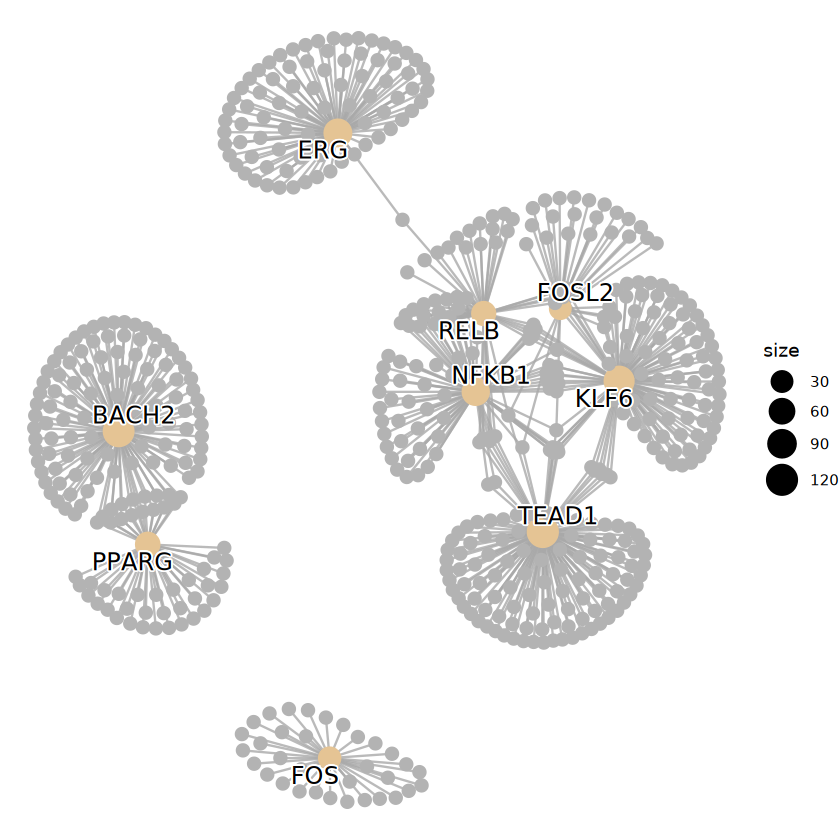

In [46]:
t

In [18]:
attributes(t)

$names
 [1] "data"        "layers"      "scales"      "guides"      "mapping"    
 [6] "theme"       "coordinates" "facet"       "plot_env"    "layout"     
[11] "labels"     

$class
[1] "ggraph" "gg"     "ggplot"

In [47]:
#attributes(t$data)

In [49]:
#str(t$data)

In [47]:
graph <- attr(t$data, "graph")

# Extract the edge list from the graph
edge_table <- as.data.frame(igraph::as_edgelist(graph))
colnames(edge_table) <- c("Source", "Target")


In [48]:
head(edge_table)

,Source,Target
,<chr>,<chr>
1,KLF6,BICC1
2,KLF6,RASEF
3,KLF6,CREB5
4,KLF6,ACKR3
5,KLF6,ARHGAP10
6,KLF6,HKDC1


In [49]:
write.csv(edge_table, "MASH_chosen_edge_table.csv", row.names = FALSE)

In [152]:
pdf("test.pdf", width = 10, height = 20)  # Adjust the dimensions as needed
print(p)
dev.off()

Warning message:
“Removed 705 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


png 
  2

In [73]:
chosen = c("CREB5_direct_+/+",  "ETS1_direct_+/+", "KLF6_direct_+/+"
          )

Warning message in cnetplot.enrichResult(x, ...):
“Use 'color.params = list(foldChange = your_value)' instead of 'foldChange'.
 The foldChange parameter will be removed in the next version.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
“Removed 374 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


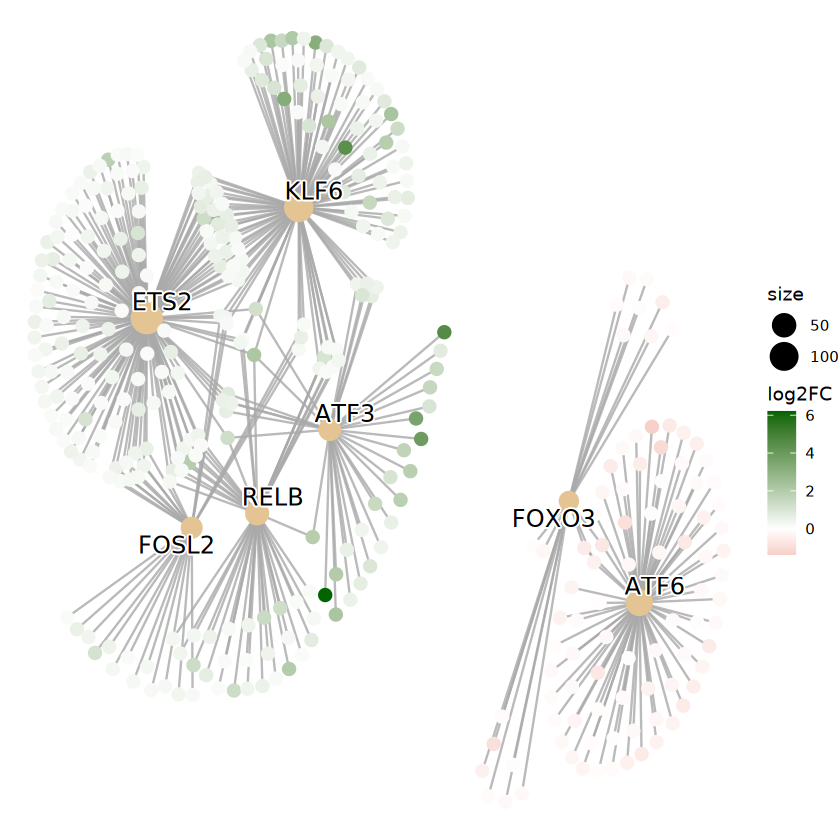

In [94]:
highlight_genes <- c("ATF3", "KLF6", "ATF6", 
               "RELB", "FOXO3", "ETS2" , "KLF10")
cnetplot(test, showCategory = chosen, categorySize="NES", node_label="category", gene_label = highlight_genes, 
         foldChange=fc) + scale_color_gradient2(name='log2FC', high='darkgreen', low='firebrick', )

Warning message in cnetplot.enrichResult(x, ...):
“Use 'color.params = list(foldChange = your_value)' instead of 'foldChange'.
 The foldChange parameter will be removed in the next version.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
“ggrepel: 287 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


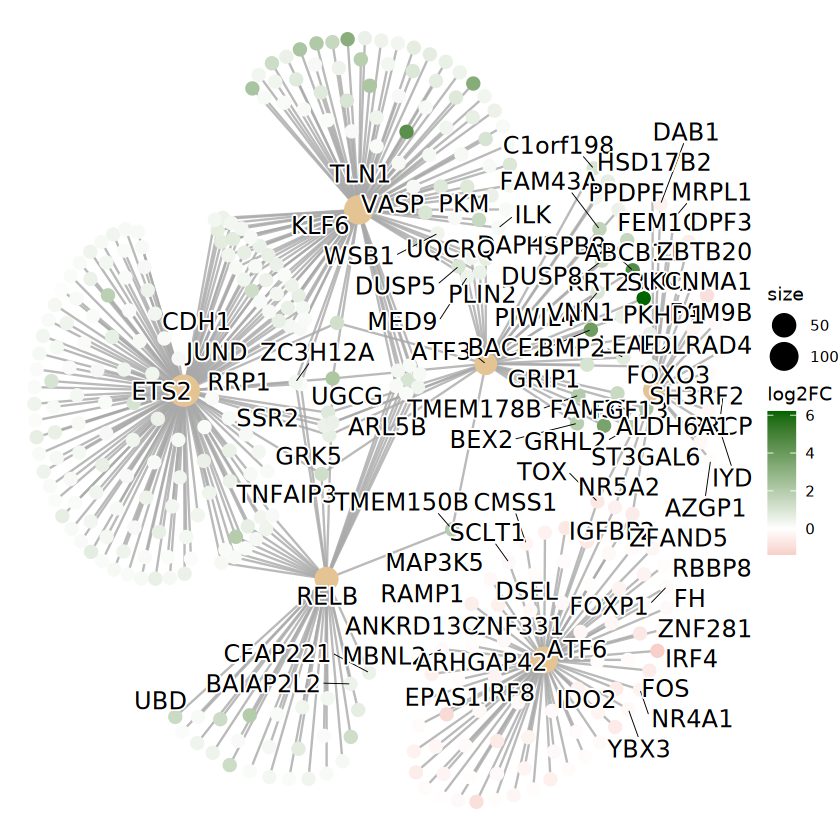

In [59]:
cnetplot(test, showCategory = chosen, categorySize="pvalue", node_label="all",  
         foldChange=fc) + scale_color_gradient2(name='log2FC', high='darkgreen', low='firebrick', )

In [103]:
#cnetplot(test, categorySize="pvalue", node_label="none")

In [74]:
test1 <- cnetplot(test, categorySize="pvalue", node_label="all", showCategory=200)

In [123]:
#test1 <- filtered_df %>%
#  filter(!grepl("_direct_\\+/-", Description))

In [75]:
graph <- attr(test1$data, "graph")

# Extract the edge list from the graph
edge_table1 <- as.data.frame(igraph::as_edgelist(graph))
colnames(edge_table1) <- c("Source", "Target")


In [76]:
head(edge_table1)

,Source,Target
,<chr>,<chr>
1,KLF12,HECTD1
2,KLF12,AOX1
3,KLF12,BPHL
4,KLF12,CYP39A1
5,KLF12,CNST
6,KLF12,NTN1


In [77]:
write.csv(edge_table1, "MASHall_edge_table.csv", row.names = FALSE)

In [95]:
write.csv(data, "MASHall_de.csv")